# Lecture13 Generative Model


# 一、 生成模型与判别式模型的核心区别

在机器学习中，模型根据其对数据概率分布的建模方式，主要分为两大阵营：

1. **判别式模型 (Discriminative Model)**
   * **核心任务**：学习条件概率分布 $p(y|x)$，即给定数据 $x$ 的情况下，标签 $y$ 的概率。
   * **特点**：试图在不同类别的标签之间划定边界。所有的“标签”在竞争概率密度（总和为1），但不对“数据（图像）”本身的分布进行建模。
   * **缺点**：无法处理不合理或分布外的输入，面对任何输入都会强制给出一个标签分布。

2. **生成模型 (Generative Model)**
   * **核心任务**：学习数据本身的联合概率分布 $p(x)$。
   * **条件生成模型**：学习 $p(x|y)$，即给定标签（如文本、条件）生成对应的数据。
   * **特点**：所有的“数据（图像）”在竞争概率密度（积分 $\int p(x)dx = 1$）。模型能够理解数据的真实分布，因此可以“拒绝”不合理的输入（赋予其极低的概率），并能够从分布中**采样 (Sample)** 生成全新的数据。
   * **贝叶斯视角的联系**：理论上可以通过贝叶斯公式利用生成模型构建判别模型，但实际工程中很少这么做（因为精确建模高维 $p(x)$ 太难）。
     $$ p(x|y) = \frac{p(y|x)p(x)}{p(y)} $$

3. **为什么要研究生成模型？**
   * **处理歧义性 (Modeling Ambiguity)**：当一个输入对应多种可能的合理输出时（如给定文本生成图像，给定前文生成后续词），我们需要模型输出一个分布 $P(x|y)$ 供我们采样。
   * **核心应用**：文本生成（大语言模型）、文生图、图像到视频预测、超分辨率、物理世界模拟（强化学习）、学习无监督特征等。

# 二、 生成模型的分类体系 (Taxonomy)

根据模型如何处理概率密度函数 $p(x)$，生成模型可分为两大流派：

1. **显式密度模型 (Explicit Density)**：模型定义了一个具体的概率密度函数 $p(x)$ 供我们计算或优化。
   * **可精确求解 (Tractable Density)**：如 **自回归模型 (Autoregressive Models)**。
   * **近似求解 (Approximate Density)**：如 **变分自编码器 (VAE)**。
2. **隐式密度模型 (Implicit Density)**：模型不显式定义 $p(x)$ 的具体公式，但可以通过某种机制直接从分布中采样。
   * **直接采样 (Direct)**：如 **生成对抗网络 (GAN)**。
   * **迭代近似采样 (Indirect)**：如 **扩散模型 (Diffusion Models)**。

# 三、 自回归模型 (Autoregressive Models)

1. **最大似然估计 (Maximum Likelihood Estimation, MLE)**
   生成模型最基本的训练思想。给定数据集，我们希望找到一组参数 $W$，使得生成这些真实数据的概率最大化。
   $$ W^* = \arg \max_W \prod_{i} p(x^{(i)}) $$
   运用 Log Trick（将连乘转化为连加，防止下溢出并简化求导），转化为我们熟悉的损失函数：
   $$ W^* = \arg \max_W \sum_{i} \log p(x^{(i)}) $$

2. **自回归的核心思想**
   利用概率论中的**链式法则 (Chain Rule)**，将高维数据（如图像的像素序列、句子的词序列）的联合概率，分解为一维条件概率的乘积：
   $$ p(x) = p(x_1, x_2, \dots, x_T) = \prod_{t=1}^T p(x_t | x_1, \dots, x_{t-1}) $$
   * **典型代表**：RNN 语言模型、Masked Transformer（大语言模型 LLM 本质上就是自回归生成模型）。

# 四、 变分自编码器 (Variational Autoencoders, VAE)

VAE 是将深度学习与统计变分推断完美结合的经典模型。

## 1. 从普通自编码器 (AE) 到概率模型
* **普通AE**：输入 $x$ 经过 Encoder 得到特征 $z$，再经过 Decoder 重建 $\hat{x}$。它不具备生成能力，因为我们不知道特征 $z$ 的空间分布，无法随机采样 $z$ 来生成有意义的图像。
* **VAE的想法**：假设真实数据 $x$ 是由某个不可见的潜在变量 $z$ 生成的。我们预先定义 $z$ 服从一个简单的**先验分布**（Prior），比如标准正态分布 $p(z) \sim \mathcal{N}(0, I)$。

## 2. 难解性危机 (Intractability)
如果我们想用最大似然估计来优化，我们需要计算数据的边缘似然：
$$ p_\theta(x) = \int p(z) p_\theta(x|z) dz $$
* 这个积分在连续高维空间中是**不可积计算的 (Intractable)**。
* 同样，真实的后验分布 $p_\theta(z|x) = \frac{p(z)p_\theta(x|z)}{p_\theta(x)}$ 也是无法计算的。

### 问题一：“哪两个高斯？MLP是啥？为什么不可积？为什么不可积就不能算Loss？”

#### 1. 哪两个高斯？
在 VAE 的生成过程中，我们要算生成图片 $x$ 的总概率 $p_\theta(x)$，它的数学公式是把所有可能的隐变量 $z$ 给积分积掉：
$$ p_\theta(x) = \int p(z) p_\theta(x|z) dz $$
在这个公式里，出现了**两个高斯分布**：
1. **先验分布 $p(z)$**：我们人为假设它是一个标准正态（高斯）分布，即 $\mathcal{N}(0, I)$。
2. **条件分布 $p_\theta(x|z)$**：也就是**解码器（Decoder）**输出的分布。我们假设给定 $z$ 之后，生成的 $x$ 也服从一个高斯分布，即 $\mathcal{N}(\mu_\theta(z), \sigma_\theta(z)^2)$。

#### 2. MLP是啥？
MLP 的全称是 **Multi-Layer Perceptron（多层感知机）**，在这里泛指**深度神经网络**（在图像中通常是用卷积神经网络 CNN）。
在这个语境下，MLP 的作用是充当**解码器**。它接收一个低维向量 $z$，然后经过一层层的矩阵乘法和非线性激活函数（如 ReLU），最终计算出那两个高斯参数：$\mu_\theta(z)$ 和 $\sigma_\theta(z)$。

#### 3. 为什么“不可积” (Intractable)？
这是一个纯数学问题。
* 如果 $\mu_\theta(z)$ 和 $\sigma_\theta(z)$ 只是 $z$ 的**简单线性函数**（比如纯粹的矩阵相乘），那么两个高斯分布相乘再积分，数学上是有解析解的（算出来的结果仍然是个高斯分布）。
* **但是！** 我们的 $\mu_\theta(z)$ 和 $\sigma_\theta(z)$ 是通过 **MLP（深度神经网络）** 算出来的。神经网络里充满了非线性激活函数（比如 ReLU, Tanh 等），这导致 $\mu_\theta(z)$ 是一个**极其复杂、高度非线性的函数**。
* 面对这样复杂的非线性函数，哪怕是最厉害的数学家，也**写不出** $\int \mathcal{N}(z; 0, I) \cdot \mathcal{N}(x; \mu_\theta(z), \sigma_\theta(z)^2) dz$ 这个积分的精确公式（这叫没有闭式解/解析解，即 **Intractable**）。

#### 4. 为什么不可积就不能算 Loss？
传统的机器学习训练生成模型，用的都是**最大似然估计（MLE）**。
我们的 Loss 函数就是让真实数据的对数似然最大化：
$$ \text{Loss} = - \sum_{i} \log p_\theta(x^{(i)}) $$
既然第3点说了，因为神经网络的存在，那个积分算不出结果，这意味着我们**连 $p_\theta(x)$ 的具体数值都求不出来**。
**如果你连目标函数的值都算不出来，你自然没法对它求导，也就没法用梯度下降来更新神经网络的参数了。** 这就是 VAE 必须引入变分推断（用 ELBO 绕开直接计算 $p_\theta(x)$）的根本原因！

---

### 问题二：纠正一个容易混淆的细节（关于 $\mu + \epsilon \cdot \sigma$）

你在提问中说：“可以通过两者 sample $x$，即 $\mu + \epsilon \sigma$，其中 $\sigma$ 又是个标准正态分布”。
这里你的理解大方向是对的（这就是大名鼎鼎的**重参数化技巧 Reparameterization Trick**），但是**变量的主语和细节稍微有点混淆**，我帮你理清一下：

* 这个技巧主要用在 **Encoder（编码器）** 采样隐变量 $z$ 的时候，而不是采样 $x$ 的时候。
* 编码器输出了 $z$ 的均值 $\mu_{z|x}$ 和方差 $\sigma_{z|x}$。我们需要从 $\mathcal{N}(\mu_{z|x}, \sigma_{z|x}^2)$ 中采样一个 $z$ 传给解码器。
* 但是“采样”这个动作是随机的，无法反向传播求导。所以我们写成：
  $$ z = \mu_{z|x} + \epsilon \cdot \sigma_{z|x} $$
* 注意：**$\epsilon$（读作 epsilon）才是那个从标准正态分布 $\mathcal{N}(0, I)$ 里采样出来的随机噪声**，而不是 $\sigma$。$\sigma_{z|x}$ 是神经网络算出来的标准差。这样一来，随机性都被隔离在 $\epsilon$ 里了，$\mu$ 和 $\sigma$ 就可以正常求导更新了。

---

### 问题三：为什么 $\mu_{x|z}$ 的维度是 $H \times W \times 3$？

这要回到**“概率分布到底代表了图像的什么”**这个物理意义上。

1. **什么是 $\mu_{x|z}$？**
   在 VAE 的设定里，解码器并不直接输出一张确定的图片，而是输出一个**图片各个像素点的概率分布**。$\mu_{x|z}$ 就是这个概率分布的**期望（均值）**。

2. **它对应的是什么实体？**
   一张彩色图片有高度（Height）、宽度（Width）和三个颜色通道（RGB），所以一张真实的图片 $x$ 的维度就是 $H \times W \times 3$（例如 $256 \times 256 \times 3$）。

3. **因为 $x$ 是这个维度，所以它的均值必然是这个维度**
   我们假设图片的**每一个像素点**都服从一个独立的高斯分布。
   既然目标是生成一张 $H \times W \times 3$ 的图片，那么解码器就必须告诉我们：**这 $H \times W \times 3$ 个像素点，每一个点的高斯分布的均值 $\mu$ 是多少？**
   因此，$\mu_{x|z}$ 本质上就是一个维度为 $H \times W \times 3$ 的张量（Tensor）。

4. **与均方误差（MSE Loss）的绝妙联系（PPT 第 85 页的知识点）**
   在实际写代码的时候，我们往往会认为，每个像素点的方差都是固定为 $1$ 的（即 $\Sigma_{x|z} = I$）。
   如果方差是固定的，那么我们要让生成的概率最大，就等价于让真实的图片 $x$ 和 神经网络算出来的均值图片 $\mu_{x|z}$ 之间的差距越小越好。
   在数学上，这正好推导出了我们最熟悉的 **MSE Loss（均方误差）**：
   $$ || x - \mu_{x|z} ||^2 $$
   **总结来说，$\mu_{x|z}$ 在实际代码里，就是解码器 (Decoder) 最终输出的那张“预测重建图片”，所以它的维度必须和真实图片完全一样，即 $H \times W \times 3$！**

## 3. 变分推断与 ELBO (核心推导)
为了解决难解性，VAE 引入了一个新的神经网络（**概率编码器**） $q_\phi(z|x)$，用它来**近似**那个无法计算的真实后验分布 $p_\theta(z|x)$。

通过数学推导（结合贝叶斯公式和期望），数据对数似然可以被拆解为：
$$ \log p_\theta(x) = \mathcal{L}(x, \theta, \phi) + D_{KL}(q_\phi(z|x) || p_\theta(z|x)) $$
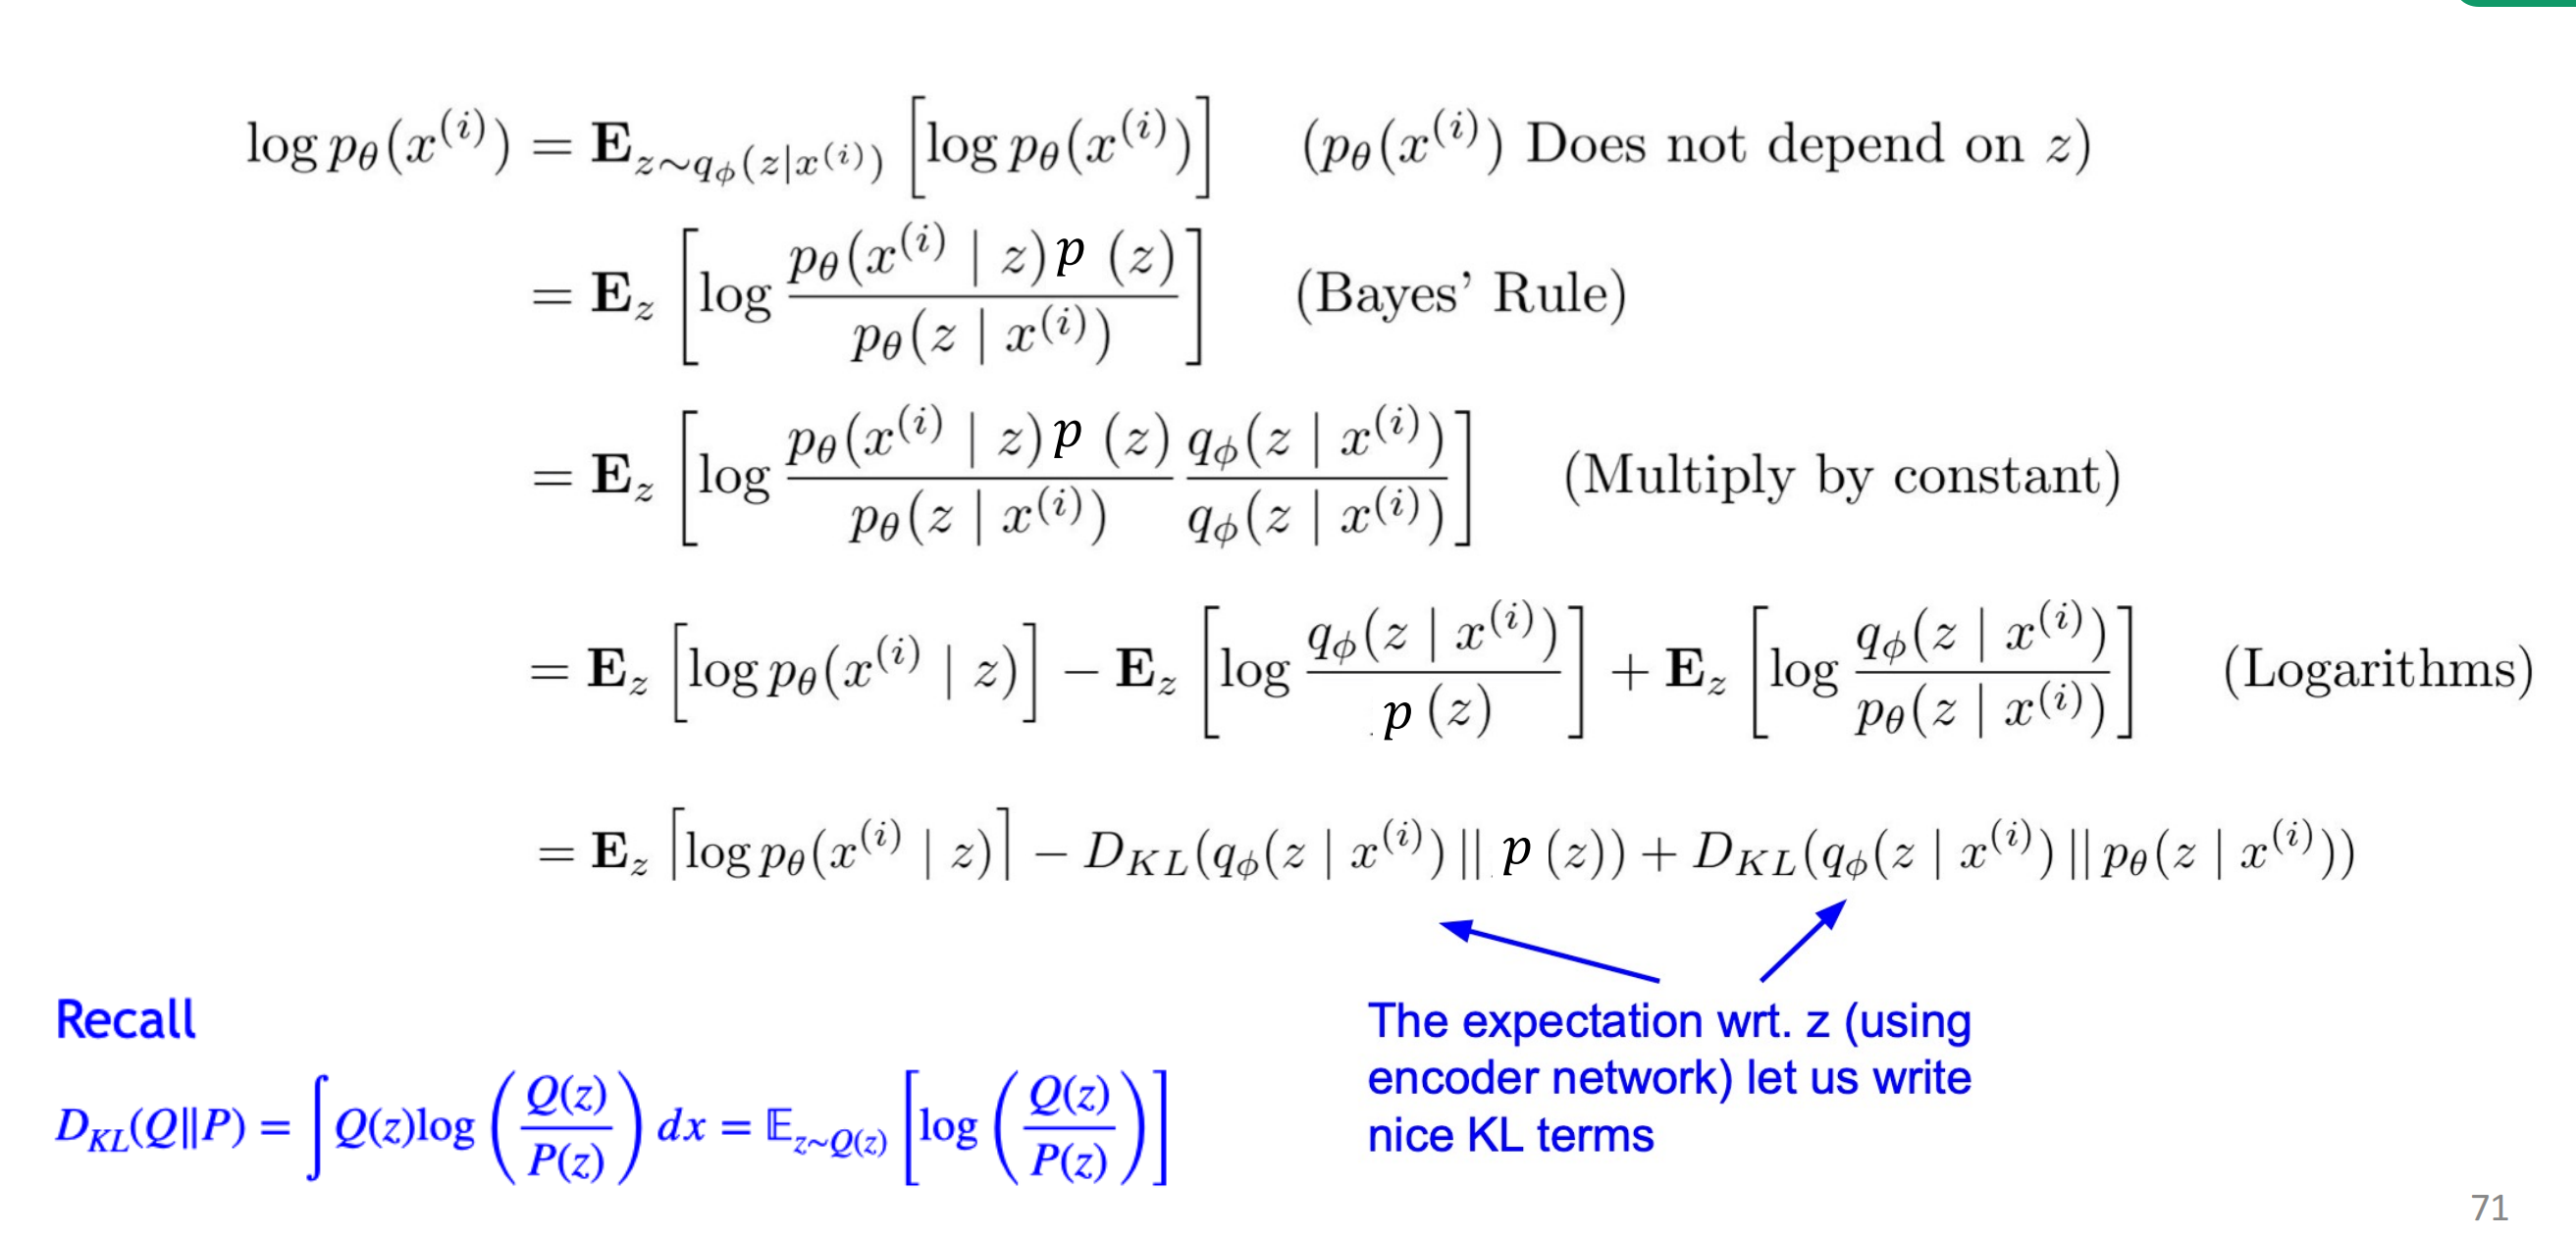
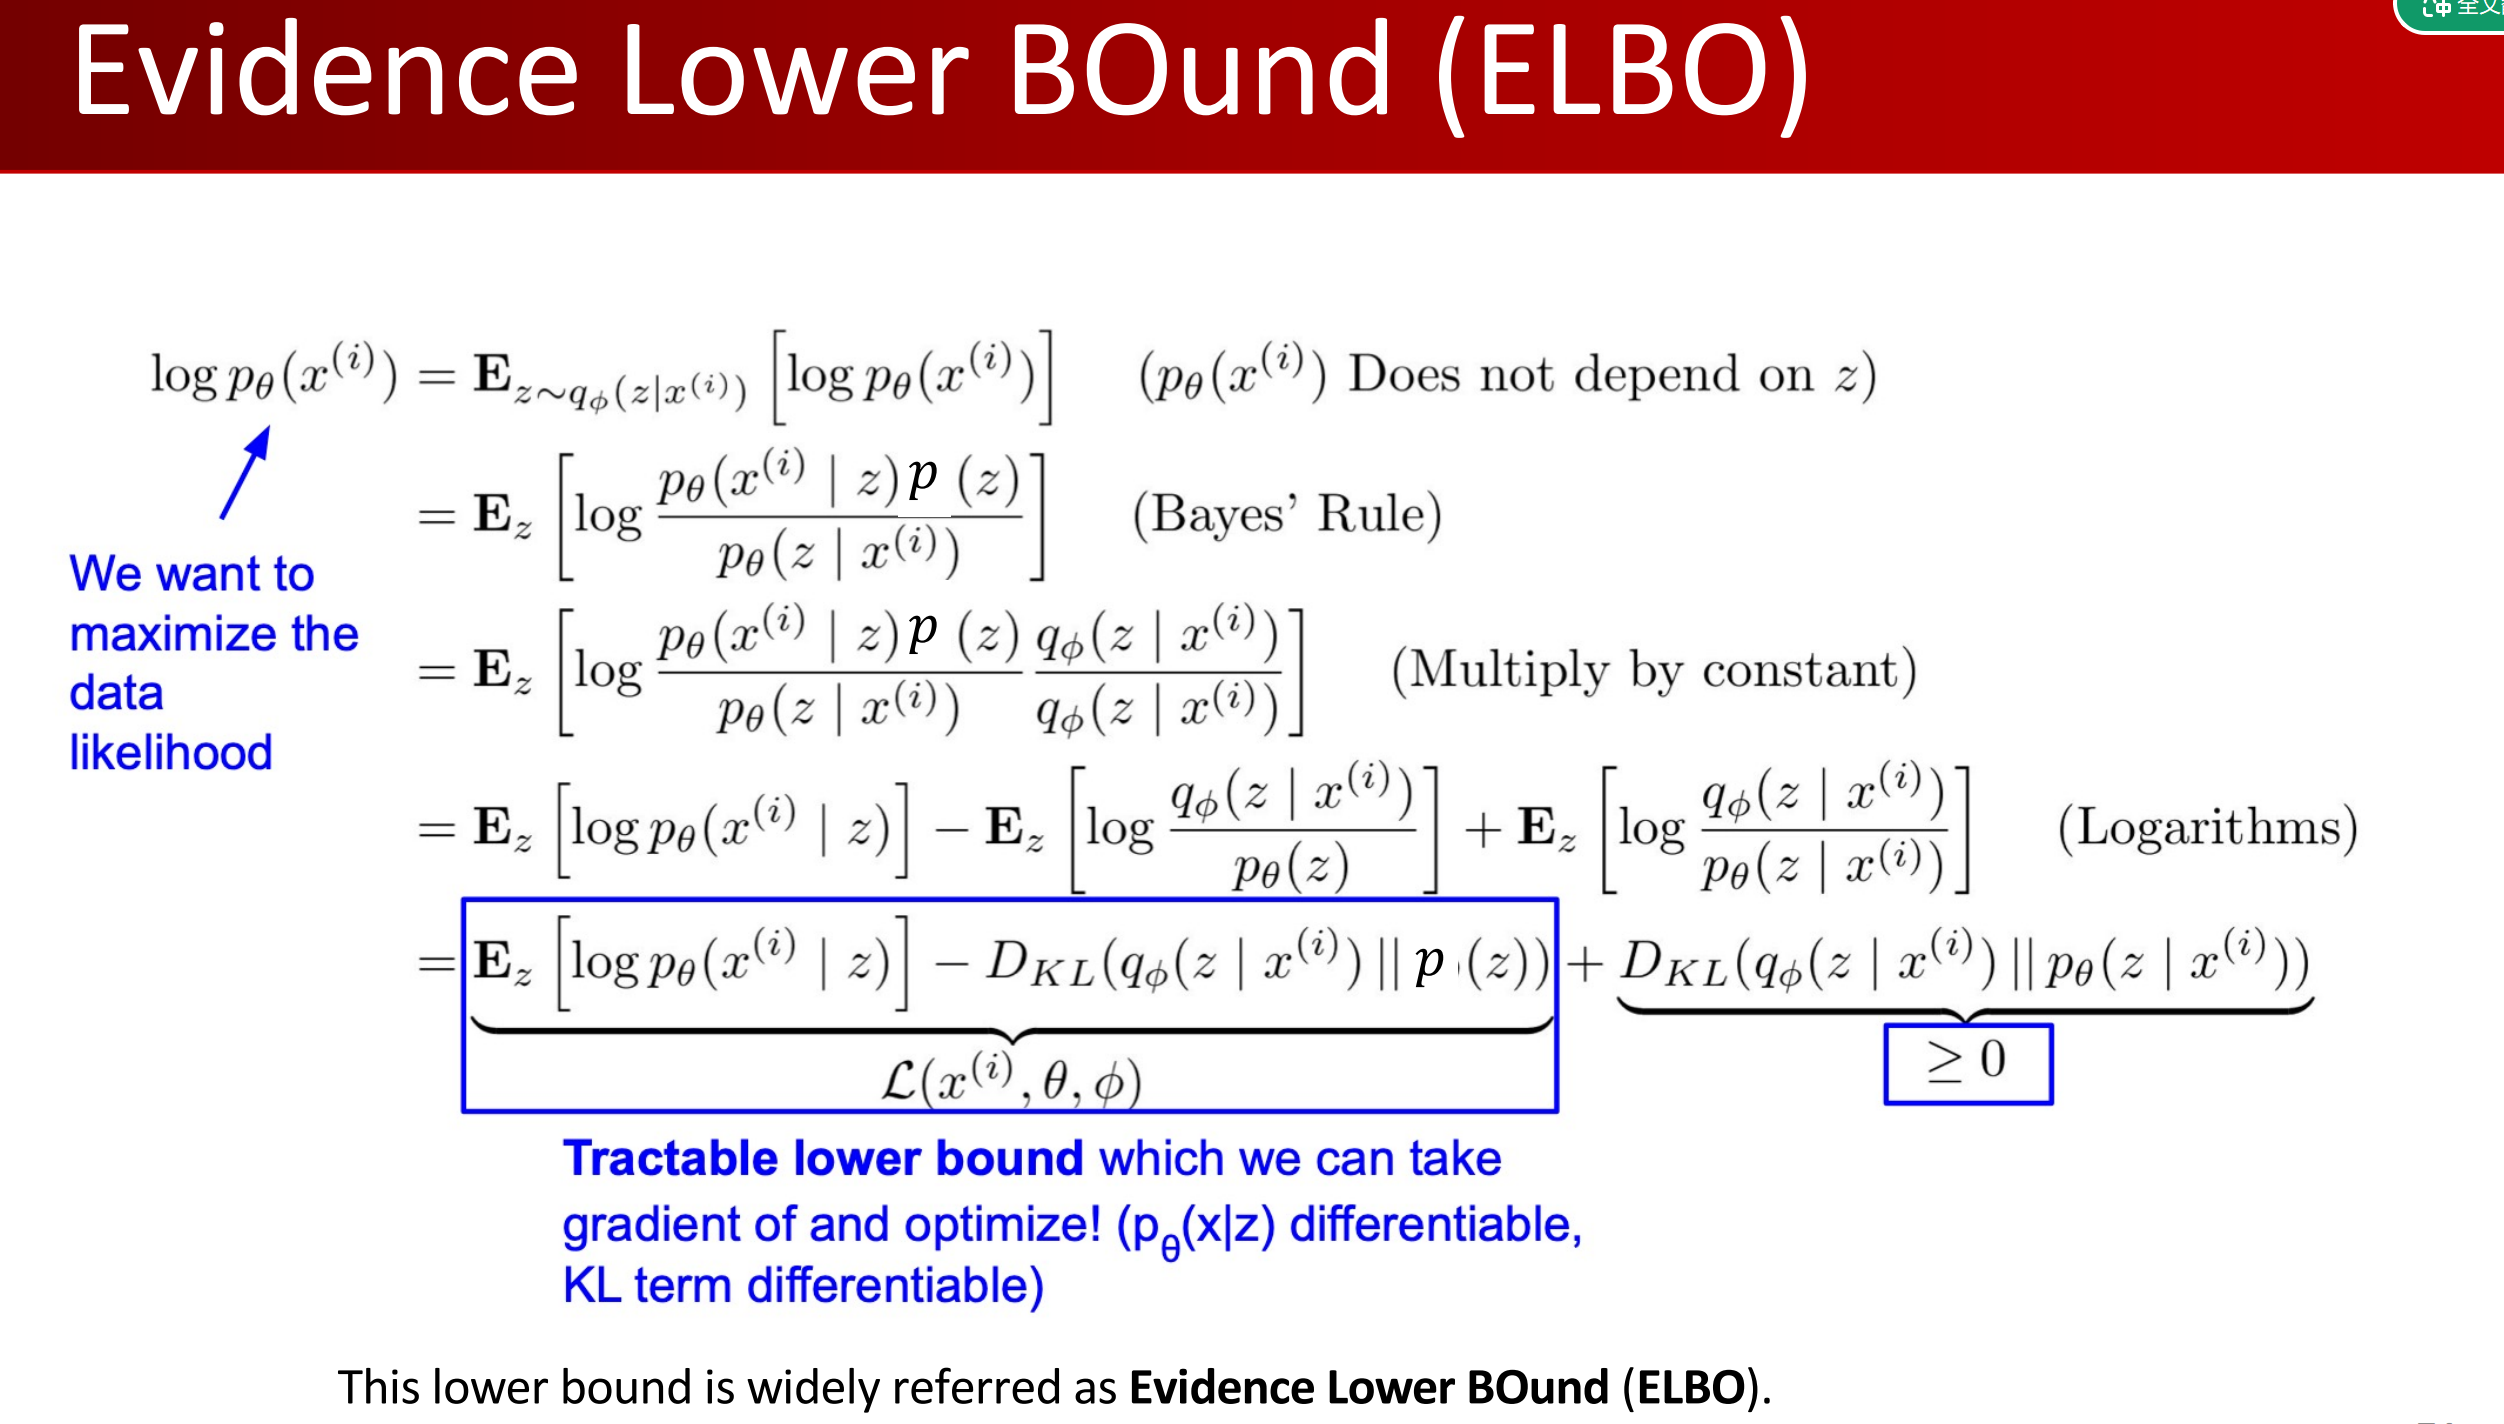
因为 KL 散度永远大于等于 0，所以 $\mathcal{L}(x, \theta, \phi)$ 是 $\log p_\theta(x)$ 的下界，被称为 **证据下界 (Evidence Lower Bound, ELBO)**。

我们无法直接最大化 $\log p_\theta(x)$，所以我们转而**最大化 ELBO**：
$$ \text{ELBO} = \mathcal{L}(x, \theta, \phi) = \mathbb{E}_{z \sim q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x) || p(z)) $$
这构成了 VAE 的损失函数（取负号即为 Loss）：
1. **重构项 (Reconstruction Term)**：$\mathbb{E}[\log p_\theta(x|z)]$。对应 Decoder，要求用采样的 $z$ 能尽量无损地还原出真实的 $x$（工程上常简化为 MSE 损失）。
2. **正则化项 (Regularization Term)**：$D_{KL}(q_\phi(z|x) || p(z))$。对应 Encoder，强迫编码器输出的近似后验分布尽量去贴合我们预设的先验分布 $\mathcal{N}(0, I)$。

## 4. 重参数化技巧 (Reparameterization Trick)
* **问题**：在训练时，我们需要从编码器预测的分布 $\mathcal{N}(\mu_{z|x}, \Sigma_{z|x})$ 中采样 $z$，然后传入解码器。但“采样”是一个随机不可导的操作，反向传播（Backprop）梯度会在这里断裂。
* **解决**：把随机性转移到一个独立的噪声变量 $\epsilon$ 上。
  先从标准正态分布采样 $\epsilon \sim \mathcal{N}(0, I)$，然后计算：
  $$ z = \mu_{z|x} + \epsilon \odot \sigma_{z|x} $$
  这样，$z$ 关于 $\mu$ 和 $\sigma$ 就变成了确定性的线性运算，梯度可以完美回传。

## 5. VAE 的采样生成过程
训练完成后，抛弃 Encoder。直接从先验分布 $\mathcal{N}(0, I)$ 中随机采样出 $z$，送入 Decoder 神经网络中，即可生成新的图像。

## 6. 补充笔记

### 第一部分：VAE Loss 的“零和博弈”（为什么两项相互限制？）

**VAE 的两个 Loss 项本质上是在互相“打架”的，它们构成了一个“信息瓶颈（Information Bottleneck）”机制。**

我们再看一眼 VAE 的 Loss（取最小化形式）：
$$ \text{Loss} = \text{Reconstruction Loss} + \text{KL Divergence} $$
$$ \text{Loss} = \mathbb{E}_{z \sim q(z|x)}[||x - \mu_{x|z}||^2] + D_{KL}(q_\phi(z|x) || \mathcal{N}(0, I)) $$

我们可以通过推演两个**极端情况**，来完美理解你说的“相互限制”逻辑：

#### 极端情况一：如果 KL 散度被强行训到 0 
* **现象**：这意味着编码器输出的 $q_\phi(z|x)$ 完美等价于标准正态分布 $\mathcal{N}(0, I)$。
* **灾难后果（后验坍塌，Posterior Collapse）**：
  如果对于**所有的**输入图片 $x$（不管是猫、狗还是车），编码器给出的分布**全都是**一模一样的标准正态分布，这意味着**潜变量 $z$ 完全丢失了关于 $x$ 的所有信息**。
  当解码器拿到一个完全随机的 $z$ 时，它根本不知道原始图片长什么样，自然无法重建出 $x$。此时，第一项重建 Loss 会直接爆炸。

#### 极端情况二：如果强行要求重建 Loss 达到完美（误差为 0）
* **现象**：为了完美还原细节，编码器会试图把每一张输入图片 $x$，映射为潜空间中**一个绝对确定的点**（即方差趋近于 0 的高斯分布）。
* **灾难后果（潜空间退化与过拟合）**：
  首先，一个方差为 0 的点（狄拉克函数），它和标准正态分布 $\mathcal{N}(0, I)$ 的 KL 散度是**无穷大**的，第二项 Loss 会爆炸。
  其次，如果变成一个个确定的点，潜空间就会变得千疮百孔，充满“断层”。当你真正想生成新图像，从 $\mathcal{N}(0, I)$ 中随机抽一个 $z$ 时，极有可能抽到一个未定义的“缝隙”里，解码器就会输出一团乱码。

#### 结论：妥协与平衡
VAE 并不是要让某一项达到最优，而是**在“保留足够的图像特征”和“保证潜空间的连续性”之间寻找平衡**。
* KL 散度像一根橡皮筋，把所有样本的隐编码往原点 $(0,0)$ 拉，并让它们互相融合（保证能采样）。
* 重建 Loss 则像斥力，逼着不同的图像编码彼此拉开距离（保证能重建）。
这两者天然互斥，不可能同时最优。

---

### 第二部分：为什么 VAE 生成的图像总是“糊”的？（L2 Loss 与高斯的锅）

这也是很多初学者疑惑的地方：为什么说“假设它是高斯分布”和“用 L2 Loss”是一回事？为什么这就导致了模糊？

其实这里的逻辑链条分为三步：

#### 第 1 步：数学上的等价性（高斯分布 $\iff$ L2 Loss）
在最大似然估计中，如果我们假设解码器生成的像素分布 $p_\theta(x|z)$ 是一个**方差恒定的独立高斯分布**，即 $x \sim \mathcal{N}(\mu_{x|z}, \sigma^2 I)$。
当我们求它的负对数似然（Negative Log-Likelihood）时，数学推导如下：
$$ -\log p_\theta(x|z) = -\log \left( \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{||x - \mu_{x|z}||^2}{2\sigma^2}\right) \right) $$
把对数拆开并去掉常数项，你会发现，我们要最小化的目标就只剩下：
$$ \text{Minimize:} \quad ||x - \mu_{x|z}||^2 $$
这就是我们熟悉的 **MSE (均方误差) 或称 L2 Loss**。
**结论：在代码里写 L2 Loss，等价于你在数学上强制假设了模型输出的像素服从单峰高斯分布。**

#### 第 2 步：L2 Loss 的“求稳”策略（导致模糊的直接原因）
L2 Loss 惩罚的是**误差的平方**。
假设模型要生成人脸上一根头发的边缘。由于 VAE 从 $z$ 采样带有随机性（或者是模型本身的表达能力不足），模型其实**并不确定**这根头发到底是在坐标的左边1个像素，还是右边1个像素。
* 如果模型猜“左边”，但真实答案在“右边”，L2 Loss 会惩罚 $2^2 = 4$ 的巨大误差。
* 为了**把平均误差降到最低**，L2 Loss 驱使模型做出最保守、最圆滑的选择——**输出左边和右边的平均值**（即灰色）。
把图像中所有边缘、纹理的不确定性全部“求平均”后，清晰锐利的边缘消失了，取而代之的就是一层蒙版一样的“模糊（Blurry）”。

#### 第 3 步：高斯分布的“单峰性”限制
真实世界的数据分布往往是**多峰的（Multimodal）**。
比如，生成一片叶子，它可能是**翠绿色**的，也可能是**枯黄色**的，但这两种颜色都是极其清晰的真实状态。
但 VAE 强制假设输出是一个**单峰高斯分布（只能有一个中心点）**。为了同时兼顾这两种可能性，这个高斯分布的均值会被迫落在“绿色”和“黄色”的中间——变成一种**浑浊的土灰色**。

#### 对比理解：为什么 GAN 不糊？
GAN 抛弃了 L2 Loss 和高斯假设。
GAN 用的是判别器。如果 GAN 敢像 VAE 那样为了求稳而输出一张“模糊的平均脸”，判别器会立刻识别出“真实世界里不存在这种糊糊的人脸”，直接给它打 0 分。
因此，GAN 被逼着在不确定时**必须做选择**（要么生成极度清晰的绿叶，要么生成极度清晰的黄叶），哪怕选错了，也比生成一张模糊的中间态要好。这就是 GAN 高清逼真的原因。

# 五、 生成对抗网络 (Generative Adversarial Networks, GAN)

如果说 VAE 还在纠结怎么通过近似方法去算密度函数，GAN 则彻底放弃了显式建模密度函数，转而通过博弈论直接学习如何“伪造”数据。

## 1. 核心思想：双玩家博弈 (Two-Player Game)
* **生成器 (Generator, G)**：输入随机噪声 $z \sim p(z)$，输出伪造图像 $G(z)$。目标是尽可能骗过判别器。
* **判别器 (Discriminator, D)**：输入一张图像，输出它是“真实数据”的概率（0~1之间）。目标是准确区分真实图片 $x$ 和伪造图片 $G(z)$。

## 2. Minimax 目标函数
GAN 的训练是一个极小极大化博弈：
$$ \min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p(z)}[\log (1 - D(G(z)))] $$
* 对于 **D**：希望最大化这个式子，即让真正的图像 $D(x)$ 接近1，让生成的假图像 $D(G(z))$ 接近0。
* 对于 **G**：希望最小化这个式子，即让生成的假图像 $D(G(z))$ 尽量接近1（骗过D）。

## 3. 训练难点与工程优化
* **梯度消失问题**：如果按照原公式训练生成器，当判别器太强时（$D(G(z)) \approx 0$），$\log(1 - 0)$ 的曲线非常平缓，导致生成器接收不到梯度，无法更新。
* **启发式替代目标 (Heuristic Objective)**：实践中，通常不让 G 去“最小化自己被识破的概率”，而是让 G 去**“最大化自己骗过 D 的概率”**：
  $$ \text{Generator Loss:} \quad \max_G \mathbb{E}_{z \sim p(z)} [\log (D(G(z)))] $$
  这在初期能提供极大的梯度信号（Gradient Ascent）。

## 4. 深度卷积GAN (DCGAN) 与架构演进
早期的 GAN 极不稳定，DCGAN 提出了一系列保持稳定的架构准则：
* 去掉全连接层，使用跨步卷积（Strided convolutions）代替池化层。
* 在 G 和 D 中都广泛使用 Batch Normalization。
* 生成器 G 使用 ReLU（输出层用 Tanh），判别器 D 统一使用 LeakyReLU。
* *后续发展*：GAN Zoo 迎来了大爆发，出现了优化损失的 Wasserstein GAN (WGAN)、能控制生成的 Conditional GAN (CGAN)、高质量生成的 BigGAN 和 StyleGAN 系列等。

## 5. 潜在空间 (Latent Space) 的向量算术
GAN 展现出了极强且可解释的潜在空间线性结构。例如经典的向量加减：
`[微笑的女人]` - `[面无表情的女人]` + `[面无表情的男人]` = `[微笑的男人]`
这说明输入噪声 $z$ 并不是无意义的乱码，其不同的方向和维度编码了高级的语义属性。